In [1]:
# import required packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# prerequisities

import warnings
warnings.filterwarnings(action="ignore")


In [3]:
df=pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
# get the statistical informantion about the dataset
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
# basic info about the dataser
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


<Axes: >

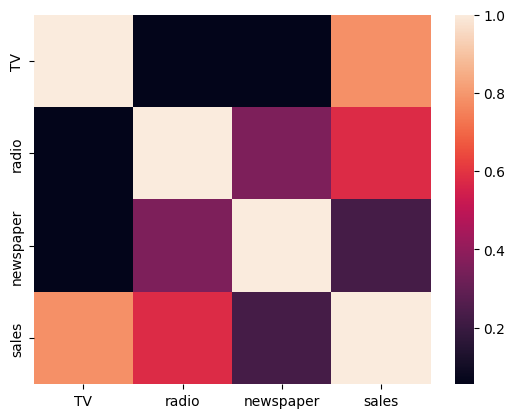

In [7]:
sns.heatmap(df.corr())

In [8]:
# create x

x=df.drop(['sales'],axis=1)

# create y
y=df['sales']

## Split the data in train and test

In [9]:
from sklearn.model_selection import train_test_split

# split the data
x_train,x_test,y_train,y_test= train_test_split(x,y,train_size=0.8,random_state=123456)

In [10]:
x_train

,TV,radio,newspaper
100,222.4,4.3,49.8
14,204.1,32.9,46.0
29,70.6,16.0,40.8
21,237.4,5.1,23.5
72,26.8,33.0,19.3
...,...,...,...
43,206.9,8.4,26.4
171,164.5,20.9,47.4
56,7.3,28.1,41.4
49,66.9,11.7,36.8


## build the model

In [11]:
from sklearn.linear_model import LinearRegression

# create the model
model=LinearRegression()

#fit the train data to generate the model
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
x_train.columns

Index(['TV', 'radio', 'newspaper'], dtype='object')

In [13]:
# predict the data
y_pred=model.predict(x_test)

In [14]:
x_test

,TV,radio,newspaper
107,90.4,0.3,23.2
188,286.0,13.9,3.7
88,88.3,25.5,73.4
109,255.4,26.9,5.5
186,139.5,2.1,26.6
127,80.2,0.0,9.2
168,215.4,23.6,57.6
81,239.8,4.1,36.9
105,137.9,46.4,59.0
7,120.2,19.6,11.6


In [16]:
y_pred

array([ 7.01291451, 18.62815025, 11.70501306, 19.74688695,  9.59938026,
        6.51601053, 17.17662529, 14.55117176, 18.05291676, 12.1401202 ,
        9.94696835, 14.20214846,  6.0236381 ,  7.36704292, 12.4629128 ,
       17.03560268,  8.81794128, 13.28566342, 10.46991646, 13.87452995,
       14.75658305, 19.82863163, 17.10308035, 20.42856337, 17.35895021,
       13.88034685, 15.05657871,  3.49463303,  8.12331545, 12.0909317 ,
       10.668898  , 20.39609263,  8.89481746,  9.09132755, 19.44989476,
        7.83679208, 12.74906844, 10.93530467, 18.43767075, 17.05499582])

### Check the performance of the model

In [17]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

MAE = mean_absolute_error(y_test,y_pred)
print(f"MAE = {MAE}")

MAE = 1.1390336904573075


In [18]:
MSE=mean_squared_error(y_test,y_pred)
print(f"MSE = {MSE}")

MSE = 2.37347009260411


In [19]:
RMSE=root_mean_squared_error(y_test,y_pred)
print(f"RMSE = {RMSE}")

RMSE = 1.5406070532761136


In [20]:
r2 =r2_score(y_test,y_pred)
print(f"R2 Score = {r2 *100 :.2f}%")

R2 Score = 88.51%


## Data Visualization

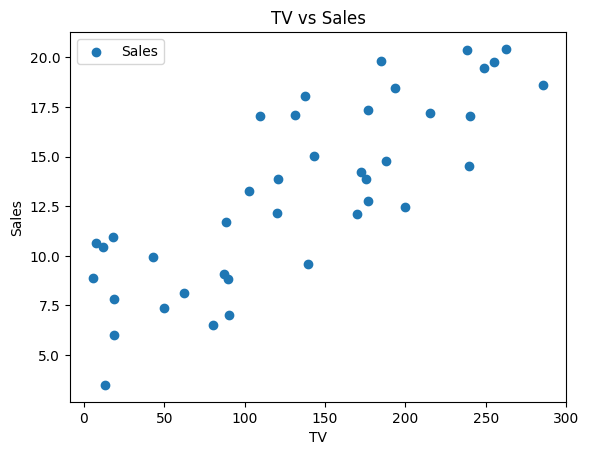

In [21]:
plt.scatter(x_test['TV'],y_pred,label='Sales')

plt.title('TV vs Sales')
plt.xlabel("TV")
plt.ylabel("Sales")
plt.legend()

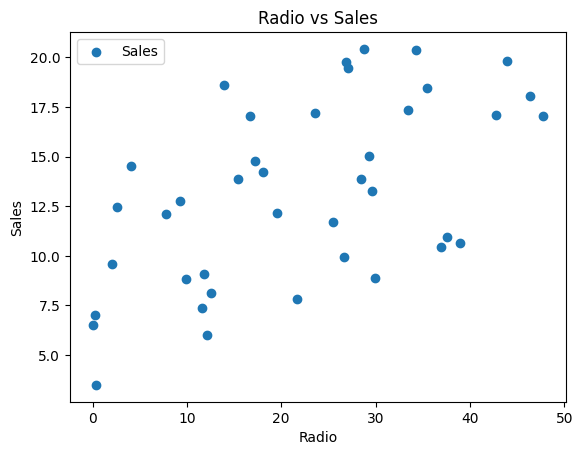

In [22]:
plt.scatter(x_test['radio'],y_pred,label='Sales')

plt.title('Radio vs Sales')
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.legend()

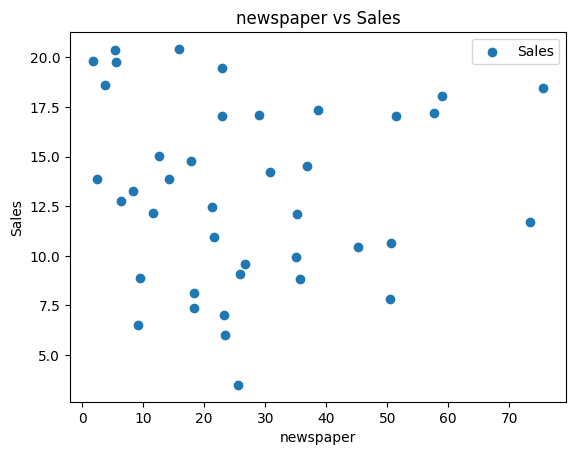

In [23]:
plt.scatter(x_test['newspaper'],y_pred,label='Sales')

plt.title('newspaper vs Sales')
plt.xlabel("newspaper")
plt.ylabel("Sales")
plt.legend()